In [12]:
import pickle

# Replace 'your_file.pkl' with the path to your .pkl file
file_path = '/home/rg625/mnt/ScoreVAE/ffhq_checkpoints/ffhq/prior/config.pkl'

# Open and load the .pkl file
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Print or process the loaded data
print(data)

sigma_0: 0.010000500828027725
sigma_1: 157.40725708007812
alpha_0: 0.9999503493309021
alpha_1: 0.006352819036692381
sigma_values: tensor([9.9642e-03, 1.0341e-02, 1.0750e-02,  ..., 1.5709e+02, 1.5725e+02,
        1.5741e+02], device='cuda:0')


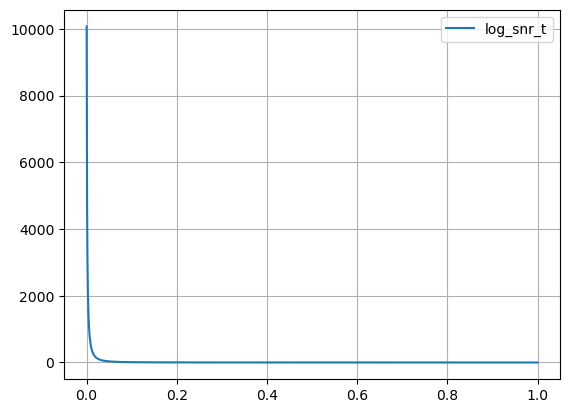

In [10]:
from sde.sde import SNRSDE
from scipy.interpolate import PchipInterpolator
import torch
import numpy as np
import matplotlib.pyplot as plt

sigma_min = 0.002
sigma_max = 80
rho = 7
N = 1000
num_diffusion_timesteps = 1000
scale = 1000 / num_diffusion_timesteps
beta_start = scale * 0.0001
beta_end = scale * 0.02
sampling_eps = 1e-5
betas = np.linspace(beta_start, beta_end, num_diffusion_timesteps, dtype=np.float64)
alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas, axis=0)
discrete_snrs = alphas_cumprod / (1.0 - alphas_cumprod)

# Monotonic Bicubic Interpolation
snr = PchipInterpolator(np.linspace(sampling_eps, 1, len(discrete_snrs)), discrete_snrs)
d_snr = snr.derivative(nu=1)

def logsnr(t):
    t = torch.tensor(t, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))  # Convert float to tensor on the correct device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    snr_val = torch.from_numpy(snr(t.cpu().numpy())).float().to(device)
    return torch.log(snr_val)

def d_logsnr(t):
    t = torch.tensor(t, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))  # Convert float to tensor on the correct device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dsnr_val = torch.from_numpy(d_snr(t.cpu().numpy())).float().to(device)
    snr_val = torch.from_numpy(snr(t.cpu().numpy())).float().to(device)
    return dsnr_val / snr_val

sde = SNRSDE(N=N, gamma=logsnr, dgamma=d_logsnr)
t_values = np.linspace(1e-5, 1, 10000)
sigma_t = sde.edm_sigma(t=t_values) 
s_t = sde.edm_s(t=t_values) 
log_snr_t = logsnr(t=t_values)
snr_experimental = (1/sigma_t).log()

print(f"sigma_0: {sde.edm_sigma(t=t_values[0])}")
print(f"sigma_1: {sde.edm_sigma(t=t_values[-1])}")
print(f"alpha_0: {sde.edm_s(t=t_values[0])}")
print(f"alpha_1: {sde.edm_s(t=t_values[-1])}")
# print(f"sigma_values: {sigma_t}")

# plt.plot(t_values[:], sigma_t.cpu().numpy())
# plt.plot(t_values[:], s_t.cpu().numpy())
# plt.plot(t_values[:], snr_experimental.cpu().numpy(), label='snr_experimental')
plt.plot(t_values[:], log_snr_t.exp().cpu().numpy(), label='log_snr_t')
plt.grid()
plt.legend()
plt.show()

In [18]:
def get_inverse_edm_sigma_fn(sde):
    from scipy.optimize import root_scalar

    def inverse_edm_sigma_fn(edm_sigma_t):
        """Finds t such that f(t) = x using root-finding"""
        def f(t, sigma):
            # Ensure we get a scalar value
            edm_value = sde.edm_sigma(t)
            if edm_value.dim() > 0:  # Check if it's a tensor with more than one element
                edm_value = edm_value.item()  # Convert to a Python scalar
            return edm_value - sigma  # Compare with the scalar sigma

        roots = []
        if edm_sigma_t.dim() > 0:  # Only iterate if edm_sigma_t has more than 0 dimensions
            for sigma in edm_sigma_t:  # Iterate over each element in edm_sigma_t
                root_result = root_scalar(f, args=(sigma.item(),), bracket=[0., 1.], method='brentq')
                if root_result.converged:
                    roots.append(root_result.root)
                else:
                    roots.append(float('nan'))  # Handle non-convergence
        else:
            # Handle the case where edm_sigma_t is a single scalar
            root_result = root_scalar(f, args=(edm_sigma_t.item(),), bracket=[0., 1.], method='brentq')
            if root_result.converged:
                roots.append(root_result.root)
            else:
                roots.append(float('nan'))  # Handle non-convergence

        return torch.tensor(roots)  # Return as a tensor
    
    return inverse_edm_sigma_fn

inverse = get_inverse_edm_sigma_fn(sde)

print(inverse(torch.tensor(0.02)).cpu().numpy())

[0.00227528]
